In [ ]:
!pip install ultralytics

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture Frame';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

<IPython.core.display.Javascript object>

Saved to photo.jpg

0: 480x640 1 person, 1 bottle, 1 toothbrush, 10.9ms
Speed: 1.8ms preprocess, 10.9ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


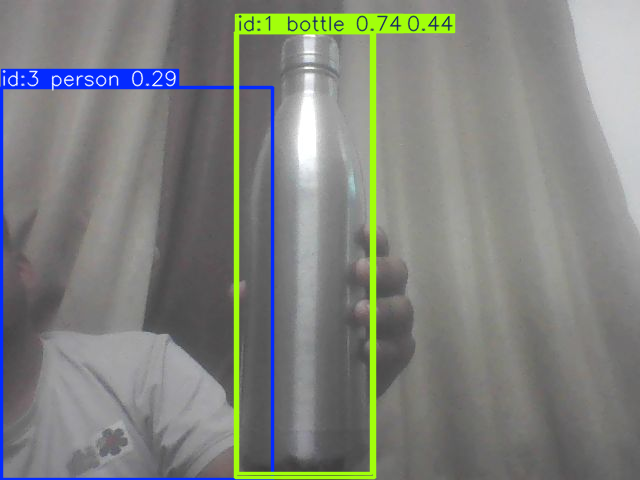

In [ ]:
# 1. Load the pre-trained YOLOv8 model (Small version for speed)
model = YOLO('yolov8n.pt')

try:
  # 2. Capture frame from JavaScript Webcam
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # 3. Read image using OpenCV
  frame = cv2.imread(filename)

  # 4. Perform Detection & Tracking
  # persist=True maintains IDs across frames if you were running a loop
  results = model.track(frame, persist=True)

  # 5. Visualize the results
  annotated_frame = results[0].plot()

  # 6. Display the output
  cv2_imshow(annotated_frame)

except Exception as err:
  print(str(err))